# 🧰 Interactive Notebook: Analysis Tools

This notebook provides two key tools:
1. An **assumption-checking dashboard** for quantitative researchers
2. A **thematic coding demonstration** for qualitative researchers

---

## Assumption-Checking Dashboard (Quantitative)

Before running any parametric test, verify that your data meet the test's assumptions. This tool generates a four-panel diagnostic display for any continuous variable.

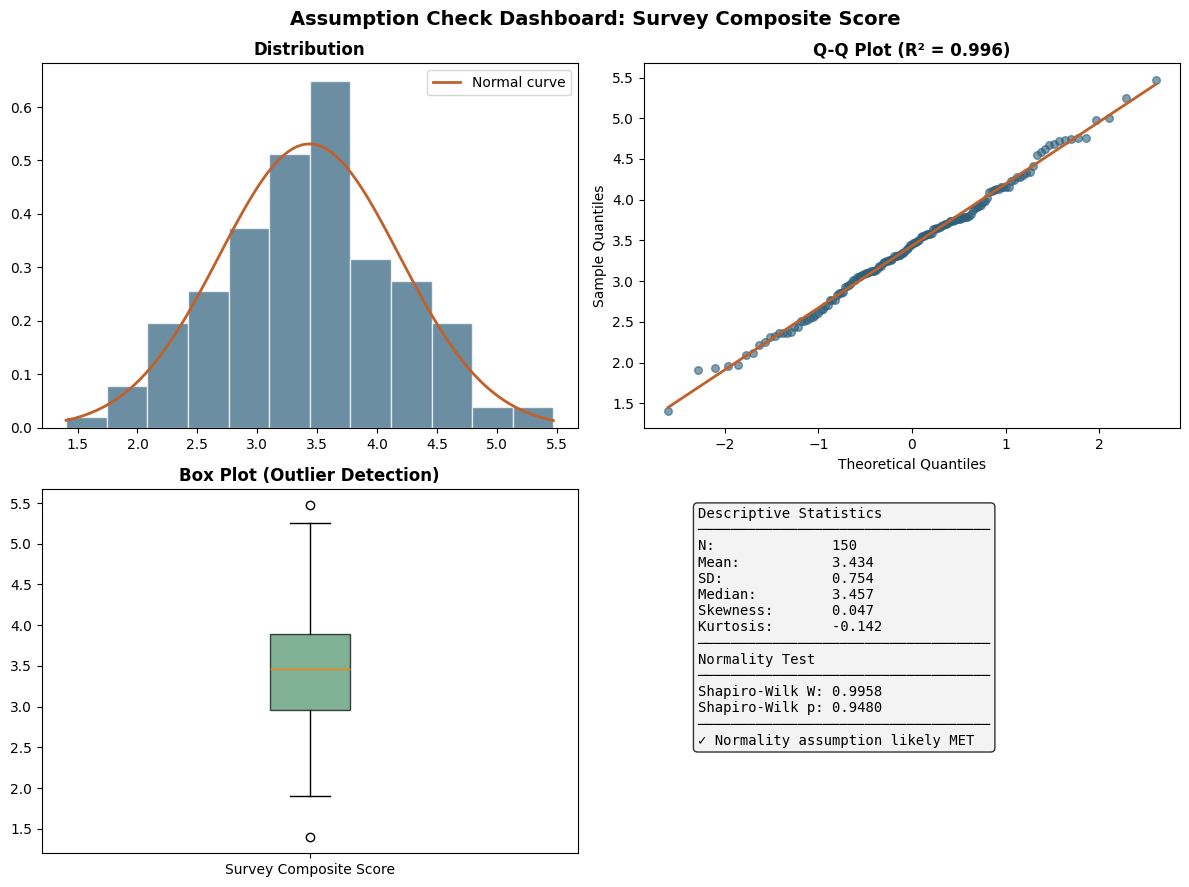


>>> Replace 'sample_data' with your own variable to check assumptions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def assumption_check_dashboard(data, variable_name="Your Variable"):
    """
    Generate a visual assumption-checking dashboard.
    
    Parameters
    ----------
    data : array-like
        The continuous variable to check
    variable_name : str
        Label for the variable
    """
    data = np.array(data, dtype=float)
    data = data[~np.isnan(data)]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f"Assumption Check Dashboard: {variable_name}",
                 fontsize=14, fontweight="bold", y=0.98)

    # 1. Histogram with normal curve
    ax = axes[0, 0]
    ax.hist(data, bins="auto", density=True, alpha=0.7, color="#2c5f7c", edgecolor="white")
    x_range = np.linspace(data.min(), data.max(), 100)
    ax.plot(x_range, stats.norm.pdf(x_range, data.mean(), data.std()),
            color="#c0612b", linewidth=2, label="Normal curve")
    ax.set_title("Distribution", fontweight="bold")
    ax.legend()

    # 2. Q-Q Plot
    ax = axes[0, 1]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    ax.scatter(osm, osr, alpha=0.6, color="#2c5f7c", s=30)
    ax.plot(osm, slope * np.array(osm) + intercept, color="#c0612b", linewidth=2)
    ax.set_title(f"Q-Q Plot (R² = {r**2:.3f})", fontweight="bold")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

    # 3. Box Plot
    ax = axes[1, 0]
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="#4a9068", alpha=0.7))
    ax.set_title("Box Plot (Outlier Detection)", fontweight="bold")
    ax.set_xticklabels([variable_name])

    # 4. Summary Statistics
    ax = axes[1, 1]
    ax.axis("off")
    shapiro_stat, shapiro_p = stats.shapiro(data[:min(5000, len(data))])
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)

    summary = (
        f"Descriptive Statistics\n"
        f"{'─'*35}\n"
        f"N:              {len(data)}\n"
        f"Mean:           {data.mean():.3f}\n"
        f"SD:             {data.std(ddof=1):.3f}\n"
        f"Median:         {np.median(data):.3f}\n"
        f"Skewness:       {skew:.3f}\n"
        f"Kurtosis:       {kurt:.3f}\n"
        f"{'─'*35}\n"
        f"Normality Test\n"
        f"{'─'*35}\n"
        f"Shapiro-Wilk W: {shapiro_stat:.4f}\n"
        f"Shapiro-Wilk p: {shapiro_p:.4f}\n"
        f"{'─'*35}\n"
    )
    if shapiro_p > 0.05:
        summary += "✓ Normality assumption likely MET"
    else:
        summary += "✗ Normality assumption may be VIOLATED"

    ax.text(0.1, 0.95, summary, transform=ax.transAxes,
            fontsize=10, verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))

    plt.tight_layout()
    plt.show()

# ─── EXAMPLE: Simulated survey composite score ───
np.random.seed(42)
sample_data = np.random.normal(loc=3.5, scale=0.8, size=150)
assumption_check_dashboard(sample_data, "Survey Composite Score")
print("\n>>> Replace 'sample_data' with your own variable to check assumptions.")

---

## Mixed Methods Design Diagrams

These visualizations illustrate the three core mixed methods designs from Creswell & Creswell (2023). Use them in your methodology chapter or presentations.

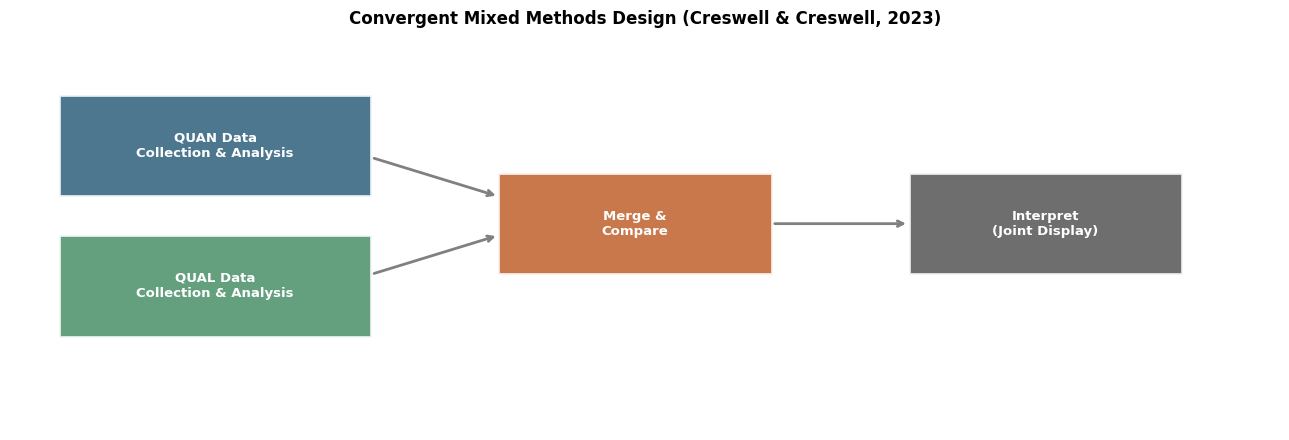

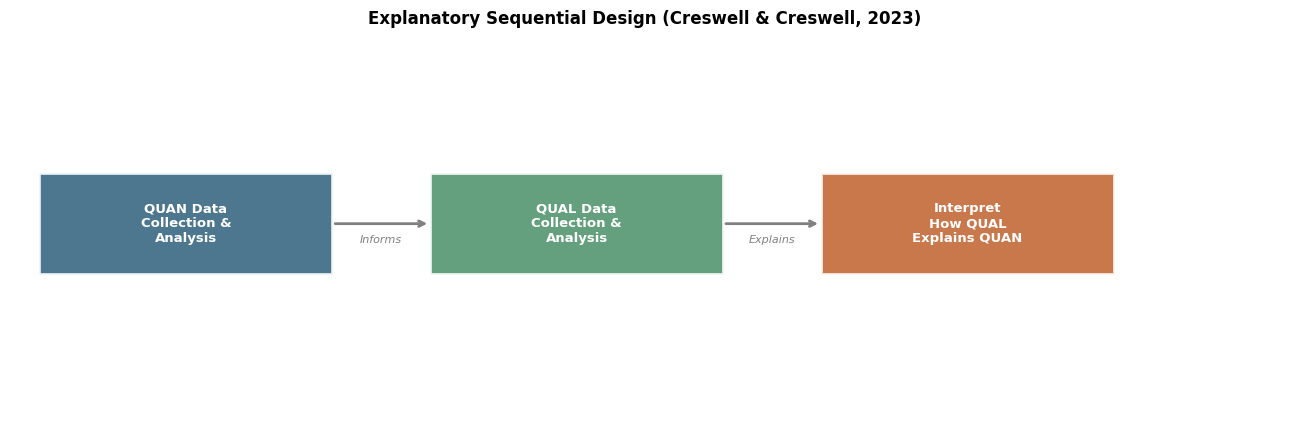

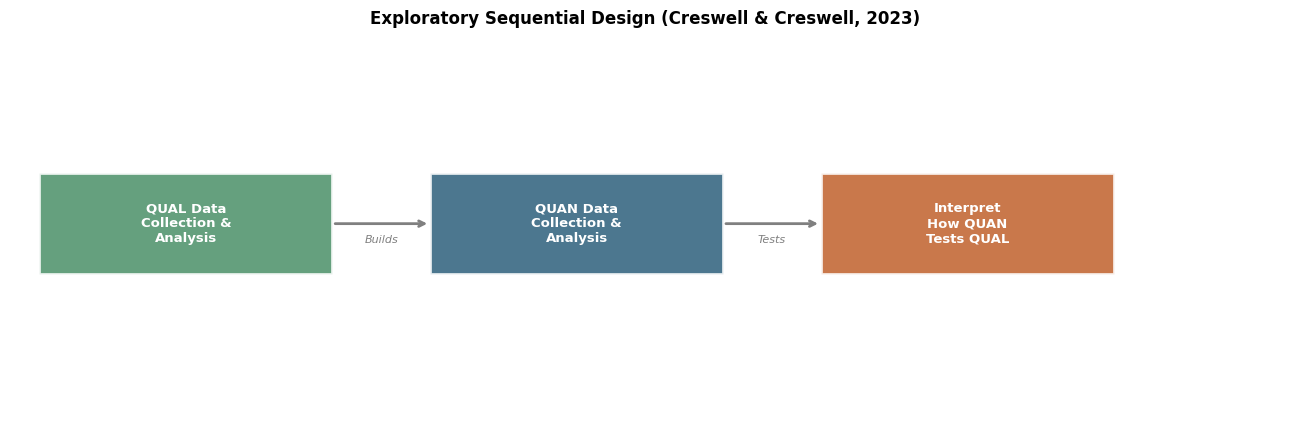

In [2]:
def mm_design_diagram(design_type="convergent"):
    """Generate a visual diagram of a mixed methods design."""
    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 5)
    ax.axis("off")

    qn = "#2c5f7c"  # QUAN color
    ql = "#4a9068"  # QUAL color
    ig = "#c0612b"  # Integration color
    gr = "#555555"  # Interpretation color

    def box(x, y, w, h, color, text):
        ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color, alpha=0.85, ec="white", lw=2))
        ax.text(x + w/2, y + h/2, text, ha="center", va="center",
                color="white", fontsize=9.5, fontweight="bold")

    def arrow(x1, y1, x2, y2, label=""):
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=2))
        if label:
            ax.text((x1+x2)/2, min(y1,y2) - 0.25, label,
                    ha="center", fontsize=8, style="italic", color="gray")

    if design_type == "convergent":
        ax.set_title("Convergent Mixed Methods Design (Creswell & Creswell, 2023)",
                     fontsize=12, fontweight="bold", pad=12)
        box(0.5, 3.0, 3.2, 1.3, qn, "QUAN Data\nCollection & Analysis")
        box(0.5, 1.2, 3.2, 1.3, ql, "QUAL Data\nCollection & Analysis")
        box(5.0, 2.0, 2.8, 1.3, ig, "Merge &\nCompare")
        box(9.2, 2.0, 2.8, 1.3, gr, "Interpret\n(Joint Display)")
        arrow(3.7, 3.5, 5.0, 3.0)
        arrow(3.7, 2.0, 5.0, 2.5)
        arrow(7.8, 2.65, 9.2, 2.65)

    elif design_type == "explanatory_sequential":
        ax.set_title("Explanatory Sequential Design (Creswell & Creswell, 2023)",
                     fontsize=12, fontweight="bold", pad=12)
        box(0.3, 2.0, 3.0, 1.3, qn, "QUAN Data\nCollection &\nAnalysis")
        box(4.3, 2.0, 3.0, 1.3, ql, "QUAL Data\nCollection &\nAnalysis")
        box(8.3, 2.0, 3.0, 1.3, ig, "Interpret\nHow QUAL\nExplains QUAN")
        arrow(3.3, 2.65, 4.3, 2.65, "Informs")
        arrow(7.3, 2.65, 8.3, 2.65, "Explains")

    elif design_type == "exploratory_sequential":
        ax.set_title("Exploratory Sequential Design (Creswell & Creswell, 2023)",
                     fontsize=12, fontweight="bold", pad=12)
        box(0.3, 2.0, 3.0, 1.3, ql, "QUAL Data\nCollection &\nAnalysis")
        box(4.3, 2.0, 3.0, 1.3, qn, "QUAN Data\nCollection &\nAnalysis")
        box(8.3, 2.0, 3.0, 1.3, ig, "Interpret\nHow QUAN\nTests QUAL")
        arrow(3.3, 2.65, 4.3, 2.65, "Builds")
        arrow(7.3, 2.65, 8.3, 2.65, "Tests")

    plt.tight_layout()
    plt.show()

for d in ["convergent", "explanatory_sequential", "exploratory_sequential"]:
    mm_design_diagram(d)
    print()

---

## Thematic Coding Demonstration (Qualitative)

This demonstrates the *computational logic* of deductive coding. It is **not** a substitute for interpretive qualitative analysis — it illustrates how codebook-based coding works systematically.

> For actual qualitative analysis, use QDA software (NVivo, QualCoder) with full interpretive engagement.

In [3]:
import re

def deductive_coding_demo(texts, codebook):
    """
    Demonstrate the logic of deductive (theory-driven) thematic coding.
    """
    results = {}
    for theme, keywords in codebook.items():
        results[theme] = {"count": 0, "segments": []}
        pattern = "|".join(re.escape(kw) for kw in keywords)
        for i, text in enumerate(texts):
            if re.search(pattern, text, re.IGNORECASE):
                results[theme]["count"] += 1
                # Show a brief preview
                results[theme]["segments"].append(f"  Seg {i+1}: \"{text[:70]}...\"")
    return results

# ─── EXAMPLE: Library user experience data ───
excerpts = [
    "I come to the library mostly for the quiet study space. It's hard to concentrate at home with kids around.",
    "The online databases are essential for my research. I couldn't do my graduate work without them.",
    "I love browsing the physical collection. There's something about discovering a book on the shelf.",
    "The librarians helped me figure out my search strategy. That consultation was incredibly valuable.",
    "I use the library's computers because I don't have reliable internet access at home.",
    "The community programs bring people together. The library is more than just books to me.",
    "I rely on interlibrary loan for materials we don't have. The system works really well.",
    "The children's section is where my kids fell in love with reading. We come every Saturday."
]

# Deductive codebook (theory-driven themes from information behavior literature)
codebook = {
    "Information Access": ["databases", "online", "internet", "access",
                          "interlibrary", "search", "materials", "computers"],
    "Space & Place":      ["space", "quiet", "study", "browsing", "shelf",
                          "physical", "collection", "section"],
    "Social Connection":  ["community", "programs", "people", "together",
                          "librarians", "helped", "consultation"],
    "Personal Growth":    ["love", "valuable", "essential", "incredibly",
                          "fell in love", "discovering"]
}

results = deductive_coding_demo(excerpts, codebook)

print("="*60)
print("  DEDUCTIVE THEMATIC CODING RESULTS")
print("="*60)
for theme, data in sorted(results.items(), key=lambda x: -x[1]["count"]):
    print(f"\n  📌 {theme}: {data['count']} segments coded")
    for seg in data["segments"]:
        print(f"    {seg}")
print("\n" + "═"*60)
print("  ⚠️  This demonstrates the LOGIC of deductive coding.")
print("  Real qualitative analysis requires interpretive depth")
print("  that cannot be reduced to keyword matching.")
print("  Use QDA software (NVivo, QualCoder) for actual analysis.")
print("═"*60)

  DEDUCTIVE THEMATIC CODING RESULTS

  📌 Information Access: 4 segments coded
      Seg 2: "The online databases are essential for my research. I couldn't do my g..."
      Seg 4: "The librarians helped me figure out my search strategy. That consultat..."
      Seg 5: "I use the library's computers because I don't have reliable internet a..."
      Seg 7: "I rely on interlibrary loan for materials we don't have. The system wo..."

  📌 Personal Growth: 4 segments coded
      Seg 2: "The online databases are essential for my research. I couldn't do my g..."
      Seg 3: "I love browsing the physical collection. There's something about disco..."
      Seg 4: "The librarians helped me figure out my search strategy. That consultat..."
      Seg 8: "The children's section is where my kids fell in love with reading. We ..."

  📌 Space & Place: 3 segments coded
      Seg 1: "I come to the library mostly for the quiet study space. It's hard to c..."
      Seg 3: "I love browsing the physical co

---

## Your Turn

**Quantitative researchers:**
1. Replace `sample_data` with your own variable and run the assumption dashboard
2. Save the output for your Block 3 deliverable
3. If assumptions are violated, describe what alternative procedures you will use

**Qualitative researchers:**
1. Examine the coding demo — how does deductive coding differ from what you'll do inductively?
2. Draft your own preliminary codebook (if using deductive/theoretical thematic analysis)
3. Describe how your coding process will differ from this keyword-matching approach

**Mixed methods researchers:**
1. Save the design diagram that matches your study
2. Draft your joint display template using the examples in this notebook
3. Specify where and how integration will occur in your timeline